In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from evaluation.shap_analysis import plot_shap_bar

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from eda.summary import data_summary
from data.feature_engineering import prepare_model_data
from data.model_features import get_grouped_model_feature_columns
from models.ridge_regression import (
    train_ridge_regression,
    predict_ridge_regression,
    get_transformed_predictions,
    get_feature_coefficients,
)
from evaluation.model_evaluation import (
    run_regression_evaluation,
    plot_actual_vs_predicted,
    plot_residual_distribution,
    plot_tail_comparison,
    plot_grouped_actual_vs_predicted,
)
from evaluation.shap_analysis import (
    run_shap_analysis,
    plot_shap_beeswarm,
    plot_shap_waterfall,
    plot_shap_importance_dataframe,
)
from export.report_exports import (
    create_report_output_dirs,
    export_report_table,
    save_report_figure,
    set_report_plot_style,
)

NOTEBOOK_NAME = "03_ridge_regression_model"

report_dirs = create_report_output_dirs(
    project_root=PROJECT_ROOT,
    notebook_name=NOTEBOOK_NAME,
)

OUTPUT_DIR = report_dirs.output_dir
FIGURE_DIR = report_dirs.figure_dir
TABLE_DIR = report_dirs.table_dir

set_report_plot_style()
sns.set_theme(style="whitegrid")

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=False,
)

print("Shape:", df.shape)
display(df.head())

data_summary_table = data_summary(df)
display(data_summary_table)

Shape: (100000, 58)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,2,0,1,0,0,8.844922,0,1,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,0,1,1,0,7.398548,0,2,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,2,1,0,1,0,8.944030,0,3,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,0,8.543108,0,1,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,1,0,1,0,7.439401,0,2,0


,dtype,missing_count,missing_pct,n_unique
alcohol_freq,str,30083,30.083,3
person_id,int64,0,0.000,100000
annual_medical_cost,float64,0,0.000,91299
log1p_annual_medical_cost,float64,0,0.000,91299
total_claims_paid,float64,0,0.000,56650
annual_premium,float64,0,0.000,55538
avg_claim_amount,float64,0,0.000,53071
monthly_premium,float64,0,0.000,12339
income,float64,0,0.000,2987
ldl,float64,0,0.000,1881


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_data_summary.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_data_summary.csv')

In [3]:
feature_cols = get_grouped_model_feature_columns(
    df,
    target_col=target
)

print(f"Number of features used: {len(feature_cols)}")
print(feature_cols)

print("Hospitalisation groups:")
print(df["hospitalizations_grouped"].value_counts().sort_index())

print("\nChronic count groups:")
print(df["chronic_count_grouped"].value_counts().sort_index())

print("\nDays hospitalised groups:")
print(df["days_hospitalized_grouped"].value_counts().sort_index())

Number of features used: 47
['age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure', 'hospitalizations_grouped', 'chronic_count_grouped', 'days_hospitalized_grouped']
Hospitalisation groups:
hospitalizations_grouped
0     91031
1      8582
2+      387
Name: count, dtype: int64

Chronic count groups:
chronic_count_grouped
0     46532
1     37579
2     13111
3      245

In [4]:
ridge_feature_summary = pd.DataFrame({
    "Item": [
        "Number of model features",
        "Target variable",
        "Target transformation",
        "Train-test split",
        "Random seed",
    ],
    "Value": [
        len(feature_cols),
        target,
        "log1p",
        "80/20",
        42,
    ],
})

display(ridge_feature_summary)

export_report_table(
    table=ridge_feature_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_feature_summary",
    caption="Baseline Ridge Regression modelling setup.",
    label="tab:03-ridge-feature-summary",
    index=False,
)

,Item,Value
0,Number of model features,47
1,Target variable,annual_medical_cost
2,Target transformation,log1p
3,Train-test split,80/20
4,Random seed,42


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_feature_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_feature_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_feature_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_feature_summary.tex')}

In [5]:
ridge_group_counts = pd.concat(
    [
        (
            df["hospitalizations_grouped"]
            .value_counts()
            .sort_index()
            .rename_axis("Group")
            .reset_index(name="n")
            .assign(Variable="Hospitalisations in last 3 years")
        ),
        (
            df["chronic_count_grouped"]
            .value_counts()
            .sort_index()
            .rename_axis("Group")
            .reset_index(name="n")
            .assign(Variable="Chronic disease count")
        ),
        (
            df["days_hospitalized_grouped"]
            .value_counts()
            .sort_index()
            .rename_axis("Group")
            .reset_index(name="n")
            .assign(Variable="Days hospitalised in last 3 years")
        ),
    ],
    ignore_index=True,
)

ridge_group_counts = ridge_group_counts[
    [
        "Variable",
        "Group",
        "n",
    ]
]

display(ridge_group_counts)

export_report_table(
    table=ridge_group_counts,
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_group_counts",
    caption="Grouped health-risk counts used in the baseline Ridge Regression model.",
    label="tab:03-ridge-group-counts",
    index=False,
    float_format="%.0f",
)

,Variable,Group,n
0,Hospitalisations in last 3 years,0,91031
1,Hospitalisations in last 3 years,1,8582
2,Hospitalisations in last 3 years,2+,387
3,Chronic disease count,0,46532
4,Chronic disease count,1,37579
5,Chronic disease count,2,13111
6,Chronic disease count,3,2452
7,Chronic disease count,4+,326
8,Days hospitalised in last 3 years,0,91031
9,Days hospitalised in last 3 years,1-3,3778


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_group_counts.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_group_counts.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_group_counts.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_group_counts.tex')}

In [6]:
ridge_result = train_ridge_regression(
    df=df,
    target_col=target,
    feature_cols=feature_cols,
    target_transform="log1p",
    use_cv=True,
    alphas=np.logspace(-3, 3, 25),
    test_size=0.20,
    random_state=42,
    numeric_impute_strategy="median",
    categorical_impute_strategy="most_frequent",
    scale_numeric=True,
    one_hot_encode=True,
)

print("Selected alpha:", ridge_result.selected_alpha)
print("Train shape:", ridge_result.x_train.shape)
print("Test shape:", ridge_result.x_test.shape)

Selected alpha: 0.1778279410038923
Train shape: (80000, 47)
Test shape: (20000, 47)


In [7]:
ridge_model_summary = pd.DataFrame({
    "Item": [
        "Model",
        "Selected alpha",
        "Training observations",
        "Test observations",
        "Number of features before preprocessing",
        "Target transformation",
        "Test size",
        "Random seed",
    ],
    "Value": [
        "Ridge Regression",
        ridge_result.selected_alpha,
        ridge_result.x_train.shape[0],
        ridge_result.x_test.shape[0],
        len(feature_cols),
        ridge_result.target_transform,
        0.20,
        42,
    ],
})

display(ridge_model_summary)

export_report_table(
    table=ridge_model_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_model_summary",
    caption="Baseline Ridge Regression model summary.",
    label="tab:03-ridge-model-summary",
    index=False,
)

,Item,Value
0,Model,Ridge Regression
1,Selected alpha,0.177828
2,Training observations,80000
3,Test observations,20000
4,Number of features before preprocessing,47
5,Target transformation,log1p
6,Test size,0.2
7,Random seed,42


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_model_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_model_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_model_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_model_summary.tex')}

In [8]:
y_pred_cost = predict_ridge_regression(
    model=ridge_result.model,
    df=ridge_result.x_test,
    target_transform=ridge_result.target_transform,
    clip_min=0,
)

y_pred_log = get_transformed_predictions(
    model=ridge_result.model,
    df=ridge_result.x_test,
)

evaluation_results = run_regression_evaluation(
    x_test=ridge_result.x_test,
    y_true=ridge_result.y_test,
    y_pred=y_pred_cost,
    y_true_transformed=np.log1p(ridge_result.y_test),
    y_pred_transformed=y_pred_log,
    actual_col="actual_cost",
    predicted_col="predicted_cost",
    transformed_actual_col="actual_log_cost",
    transformed_predicted_col="predicted_log_cost",
    group_cols=[
        "hospitalizations_grouped",
        "chronic_count_grouped",
        "days_hospitalized_grouped",
    ],
    original_scale_name="cost",
    transformed_scale_name="log",
)

predictions = evaluation_results["predictions"]
metrics_df = evaluation_results["metrics"]
tail_df = evaluation_results["tail_summary"]

display(predictions.head())
display(metrics_df)
display(tail_df.round(2))

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,had_major_procedure,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped,actual_cost,predicted_cost,residual,absolute_error,actual_log_cost,predicted_log_cost
75721,60,Male,East,Urban,30600.0,Masters,Single,Employed,4,3,...,1,1,1,4+,1640.86,4807.270425,-3166.410425,3166.410425,7.403585,8.478093
80184,40,Male,North,Rural,55900.0,Some College,Married,Employed,2,0,...,0,0,0,0,2306.61,1556.847634,749.762366,749.762366,7.743968,7.351060
19864,55,Male,East,Urban,226200.0,HS,Married,Employed,3,1,...,0,0,0,0,1015.03,2411.209718,-1396.179718,1396.179718,6.923658,7.788299
76699,40,Female,Central,Suburban,70700.0,Some College,Married,Employed,3,1,...,0,0,1,0,1136.82,2067.485403,-930.665403,930.665403,7.036869,7.634572
92991,70,Male,West,Urban,107200.0,No HS,Single,Employed,2,1,...,0,0,2,0,3990.84,3235.766336,755.073664,755.073664,8.292008,8.082330


,value
rmse_cost,2956.1487
r2_cost,0.1119
pearson_correlation_cost,0.4195
sdep_cost,2858.4197
bias_cost,754.0958
mae_cost,1663.4470
mean_actual_cost,3027.7912
mean_predicted_cost,2273.6953
median_actual_cost,2096.4650
median_predicted_cost,2048.0818


,statistic,actual_cost,predicted_cost,difference,relative_difference
0,mean,3027.79,2273.70,754.10,0.25
1,p50,2096.46,2048.08,48.38,0.02
2,p90,6324.06,3547.03,2777.03,0.44
3,p95,8695.57,4284.36,4411.21,0.51
4,p99,15189.61,6317.47,8872.14,0.58
5,max,65724.90,14170.00,51554.90,0.78


In [9]:
export_report_table(
    table=metrics_df,
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_metrics",
    caption="Baseline Ridge Regression predictive performance on the held-out test set.",
    label="tab:03-ridge-metrics",
    index=False,
    float_format="%.4f",
)

export_report_table(
    table=tail_df.round(2),
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_tail_summary",
    caption="Observed and predicted upper-tail cost summaries for the baseline Ridge Regression model.",
    label="tab:03-ridge-tail-summary",
    index=False,
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_predictions.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_metrics.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_metrics.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_tail_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_tail_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_tail_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_tail_summary.tex')}

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_actual_vs_predicted_log.png


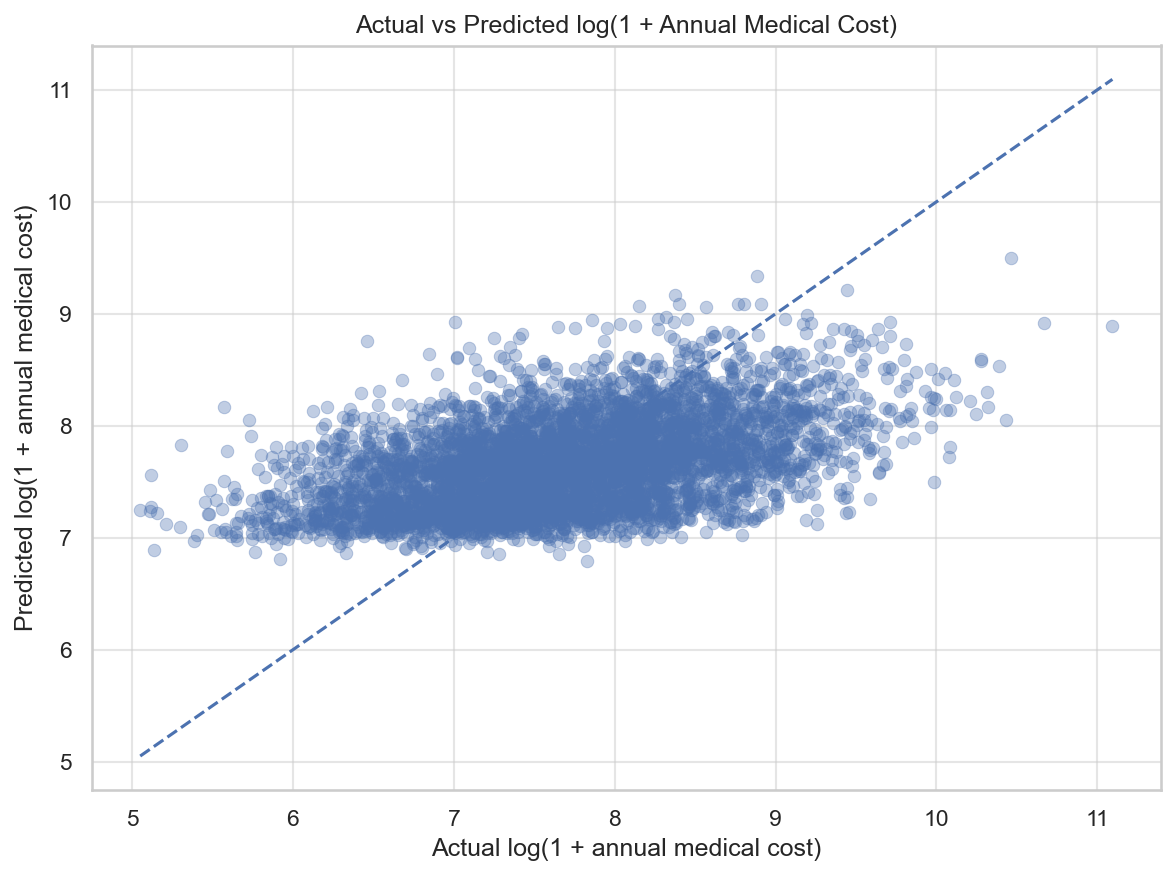

In [10]:
plot_actual_vs_predicted(
    data=predictions,
    actual_col="actual_log_cost",
    predicted_col="predicted_log_cost",
    title="Actual vs Predicted log(1 + Annual Medical Cost)",
    xlabel="Actual log(1 + annual medical cost)",
    ylabel="Predicted log(1 + annual medical cost)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_actual_vs_predicted_log",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_residual_distribution.png


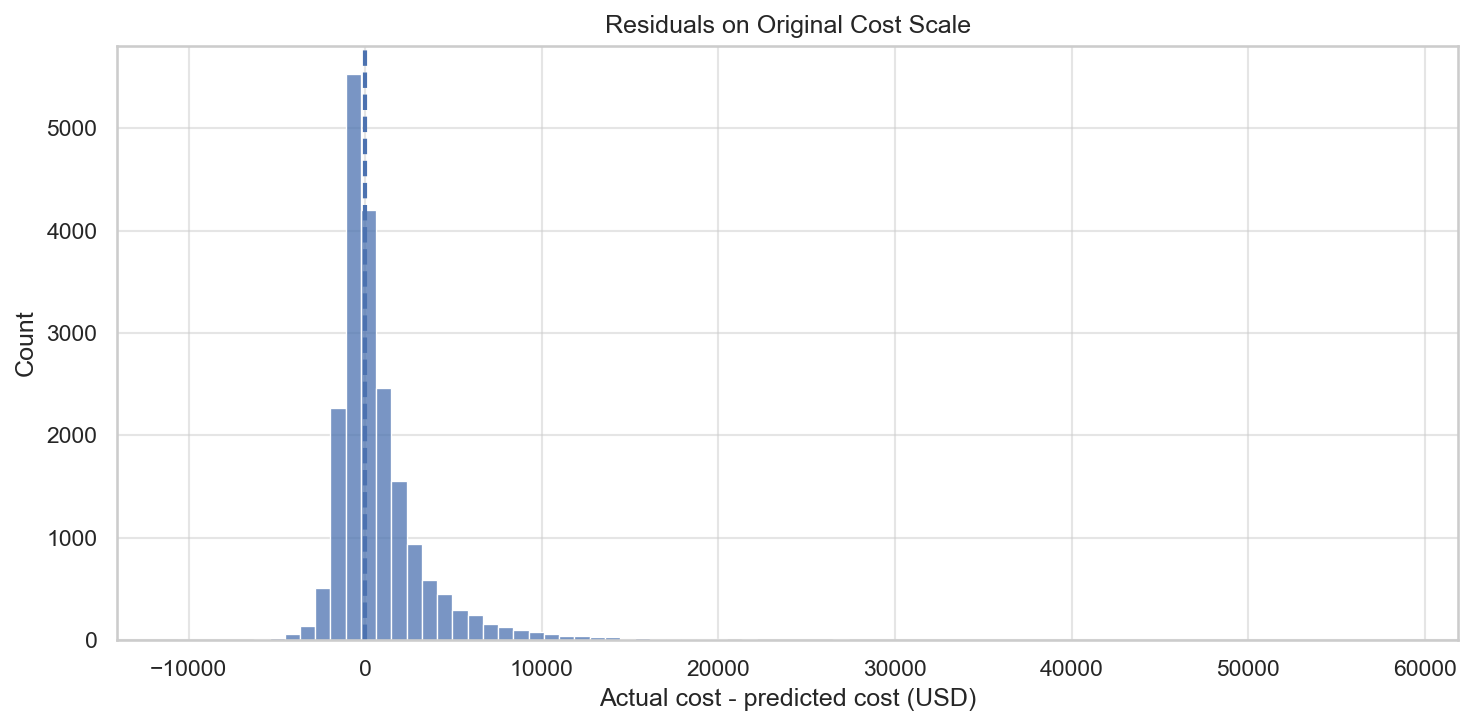

In [11]:
plot_residual_distribution(
    data=predictions,
    residual_col="residual",
    title="Residuals on Original Cost Scale",
    xlabel="Actual cost - predicted cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_residual_distribution",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_tail_percentile_comparison.png


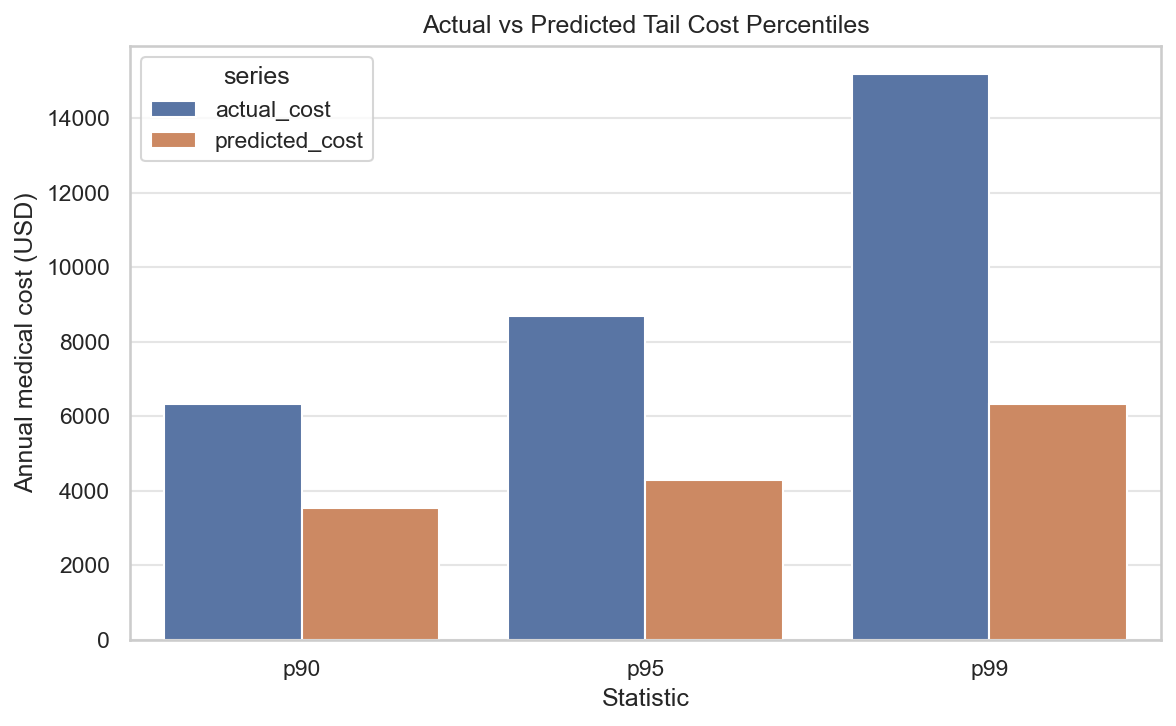

In [12]:
plot_tail_comparison(
    tail_df=tail_df,
    statistics=("p90", "p95", "p99"),
    actual_col="actual_cost",
    predicted_col="predicted_cost",
    title="Actual vs Predicted Tail Cost Percentiles",
    ylabel="Annual medical cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_tail_percentile_comparison",
)

plt.show()

In [13]:
hospital_model_summary = evaluation_results["group_summary_hospitalizations_grouped"]
chronic_model_summary = evaluation_results["group_summary_chronic_count_grouped"]
days_hospitalized_model_summary = evaluation_results["group_summary_days_hospitalized_grouped"]

display(hospital_model_summary)
display(chronic_model_summary)
display(days_hospitalized_model_summary)

,n,actual_mean,predicted_mean,actual_median,predicted_median,mae,actual_p90,predicted_p90,p90_difference,actual_p95,predicted_p95,p95_difference,actual_p99,predicted_p99,p99_difference
hospitalizations_grouped,,,,,,,,,,,,,,,
0,18188,2813.47,2108.91,1987.04,1970.81,1540.02,5833.04,3203.25,2629.78,7987.55,3664.59,4322.95,13713.35,4718.60,8994.76
1,1742,5042.25,3865.82,3657.32,3483.29,2819.41,10087.07,6081.52,4005.55,13129.64,7155.06,5974.58,23494.29,9074.29,14420.00
2+,70,8582.41,5469.12,4906.64,5122.38,4967.42,18614.89,8902.51,9712.38,28464.62,9530.63,18933.99,37382.90,11983.77,25399.13


,n,actual_mean,predicted_mean,actual_median,predicted_median,mae,actual_p90,predicted_p90,p90_difference,actual_p95,predicted_p95,p95_difference,actual_p99,predicted_p99,p99_difference
chronic_count_grouped,,,,,,,,,,,,,,,
0,9290,2212.49,1617.21,1575.86,1483.69,1212.70,4448.06,2220.36,2227.70,6168.38,2583.09,3585.29,10667.34,3469.57,7197.77
1,7506,3316.46,2519.22,2398.17,2281.89,1818.40,6755.76,3535.35,3220.41,9085.72,4168.80,4916.92,14794.49,5511.20,9283.30
2,2644,4442.01,3438.56,3249.29,3105.93,2463.70,8994.36,4945.24,4049.12,12169.45,5798.91,6370.54,19870.09,7673.53,12196.56
3,504,5793.30,4274.94,4287.90,3859.25,3148.27,10940.31,6161.44,4778.87,16011.83,7290.26,8721.57,24415.33,9614.83,14800.50
4+,56,7927.76,5261.01,6165.62,4538.03,4522.07,16432.71,8016.98,8415.73,19626.42,9831.94,9794.48,22124.42,11984.60,10139.83


,n,actual_mean,predicted_mean,actual_median,predicted_median,mae,actual_p90,predicted_p90,p90_difference,actual_p95,predicted_p95,p95_difference,actual_p99,predicted_p99,p99_difference
days_hospitalized_grouped,,,,,,,,,,,,,,,
0,18188,2813.47,2108.91,1987.04,1970.81,1540.02,5833.04,3203.25,2629.78,7987.55,3664.59,4322.95,13713.35,4718.60,8994.76
1-3,745,3934.41,3044.27,2884.85,2859.73,2276.12,7785.04,4653.24,3131.79,11561.65,5420.58,6141.07,18065.42,6698.23,11367.19
4+,1067,6048.02,4544.62,4450.08,4286.72,3339.67,11792.20,6910.92,4881.29,15435.36,7717.98,7717.38,29784.17,9884.52,19899.65


In [14]:
export_report_table(
    table=hospital_model_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_group_summary_hospitalisation",
    caption="Observed and predicted mean annual cost by hospitalisation group for the baseline Ridge Regression model.",
    label="tab:03-ridge-group-summary-hospitalisation",
    index=False,
)

export_report_table(
    table=chronic_model_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_group_summary_chronic_count",
    caption="Observed and predicted mean annual cost by chronic disease count group for the baseline Ridge Regression model.",
    label="tab:03-ridge-group-summary-chronic-count",
    index=False,
)

export_report_table(
    table=days_hospitalized_model_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_group_summary_days_hospitalised",
    caption="Observed and predicted mean annual cost by days hospitalised group for the baseline Ridge Regression model.",
    label="tab:03-ridge-group-summary-days-hospitalised",
    index=False,
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_group_summary_hospitalisation.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_group_summary_hospitalisation.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_group_summary_chronic_count.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_group_summary_chronic_count.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_group_summary_days_hospitalised.csv
Sa

{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_group_summary_days_hospitalised.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_group_summary_days_hospitalised.tex')}

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_grouped_hospitalisation_mean_cost.png


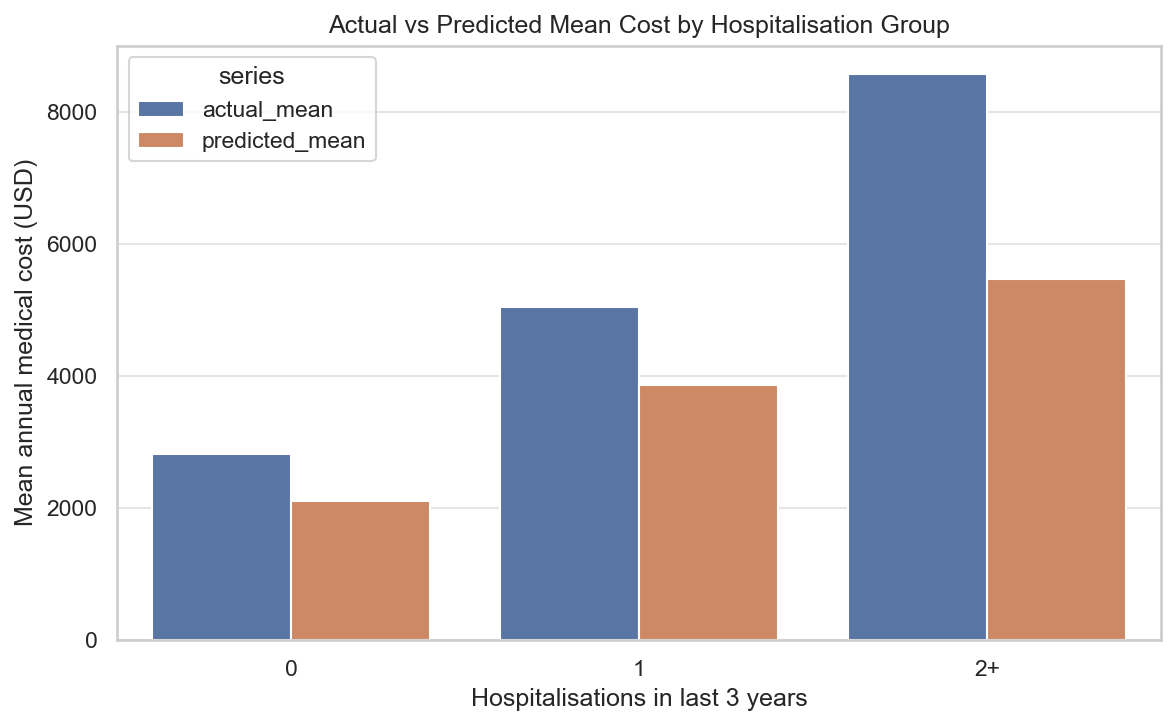

In [15]:
plot_grouped_actual_vs_predicted(
    grouped_summary=hospital_model_summary,
    group_col="hospitalizations_grouped",
    title="Actual vs Predicted Mean Cost by Hospitalisation Group",
    xlabel="Hospitalisations in last 3 years",
    ylabel="Mean annual medical cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_grouped_hospitalisation_mean_cost",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_grouped_chronic_count_mean_cost.png


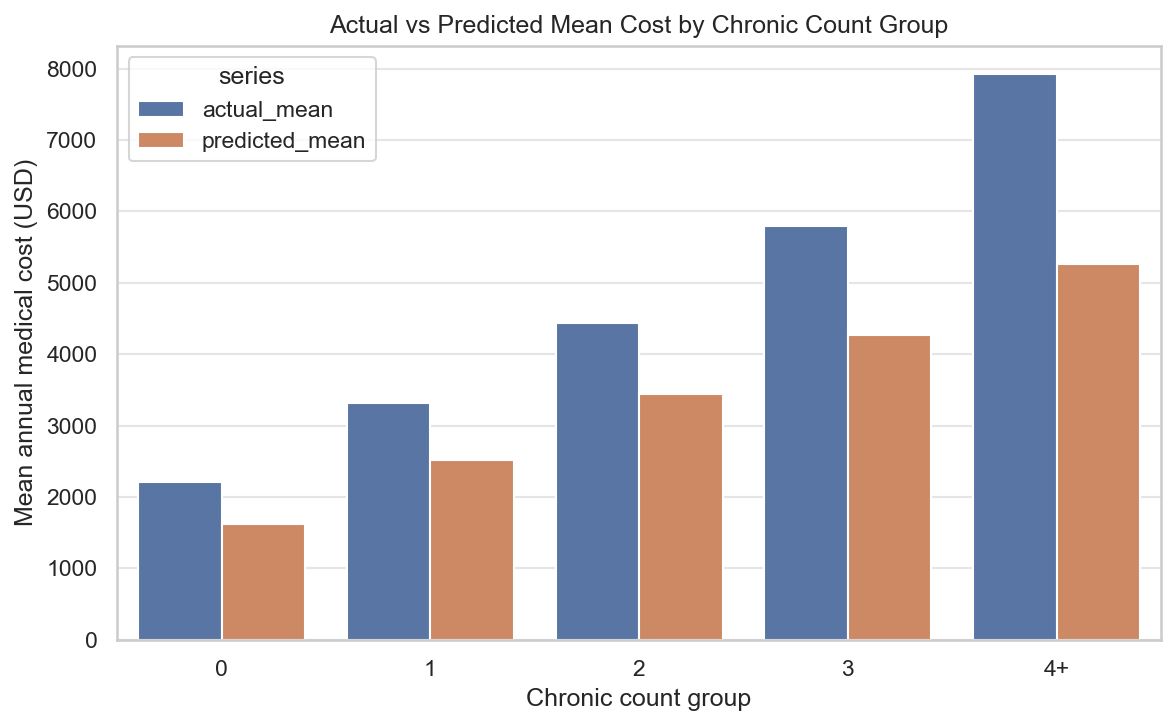

In [16]:
plot_grouped_actual_vs_predicted(
    grouped_summary=chronic_model_summary,
    group_col="chronic_count_grouped",
    title="Actual vs Predicted Mean Cost by Chronic Count Group",
    xlabel="Chronic count group",
    ylabel="Mean annual medical cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_grouped_chronic_count_mean_cost",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_grouped_days_hospitalised_mean_cost.png


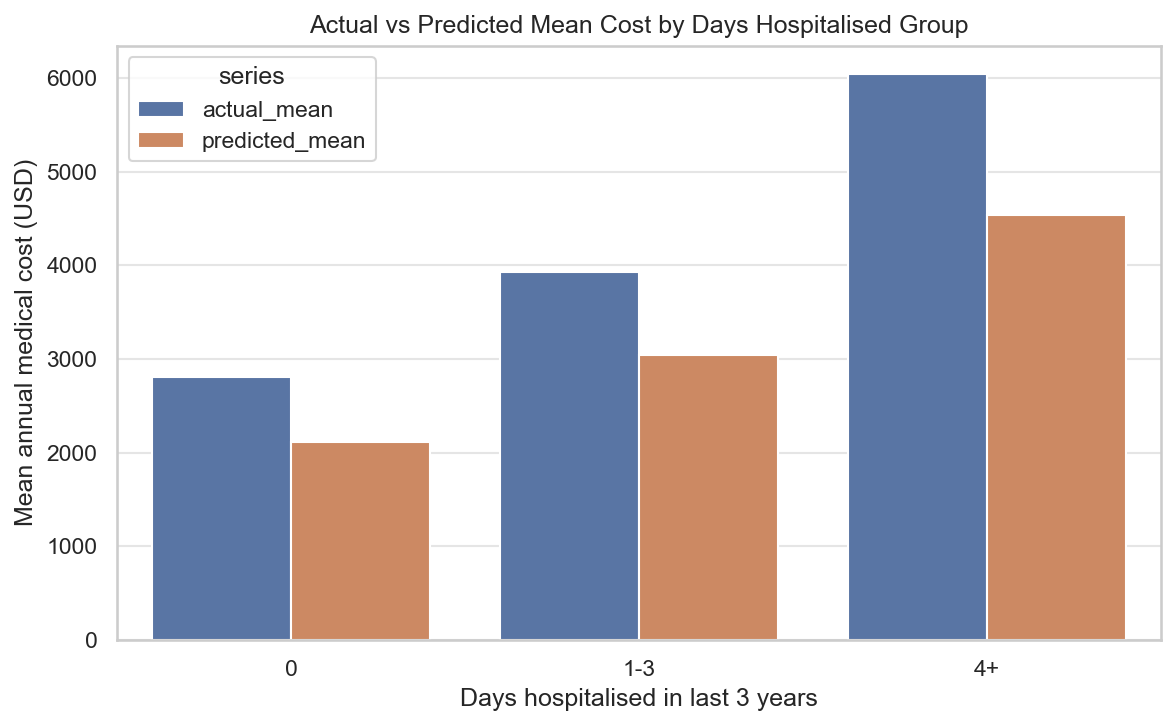

In [17]:
plot_grouped_actual_vs_predicted(
    grouped_summary=days_hospitalized_model_summary,
    group_col="days_hospitalized_grouped",
    title="Actual vs Predicted Mean Cost by Days Hospitalised Group",
    xlabel="Days hospitalised in last 3 years",
    ylabel="Mean annual medical cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_grouped_days_hospitalised_mean_cost",
)

plt.show()

In [18]:
coef_df = get_feature_coefficients(ridge_result)

display(coef_df.head(30))

,feature,coefficient,abs_coefficient
0,chronic_count_grouped_0,-0.758029,0.758029
1,chronic_count_grouped_4+,0.621683,0.621683
2,chronic_count_grouped_3,0.344975,0.344975
3,days_hospitalized_grouped_4+,0.283575,0.283575
4,chronic_count_grouped_1,-0.275090,0.275090
5,smoker_Current,0.230883,0.230883
6,hospitalizations_grouped_2+,0.202861,0.202861
7,hospitalizations_grouped_0,-0.198635,0.198635
8,days_hospitalized_grouped_0,-0.198635,0.198635
9,smoker_Never,-0.188946,0.188946


In [19]:
top_coef_export = coef_df.head(30).copy()

display(top_coef_export)

export_report_table(
    table=top_coef_export,
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_top_coefficients",
    caption="Largest baseline Ridge Regression coefficients by absolute size.",
    label="tab:03-ridge-top-coefficients",
    index=False,
    float_format="%.4f",
)

,feature,coefficient,abs_coefficient
0,chronic_count_grouped_0,-0.758029,0.758029
1,chronic_count_grouped_4+,0.621683,0.621683
2,chronic_count_grouped_3,0.344975,0.344975
3,days_hospitalized_grouped_4+,0.283575,0.283575
4,chronic_count_grouped_1,-0.275090,0.275090
5,smoker_Current,0.230883,0.230883
6,hospitalizations_grouped_2+,0.202861,0.202861
7,hospitalizations_grouped_0,-0.198635,0.198635
8,days_hospitalized_grouped_0,-0.198635,0.198635
9,smoker_Never,-0.188946,0.188946


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_top_coefficients.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_top_coefficients.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_all_coefficients.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_all_coefficients.csv')

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_top_coefficients.png


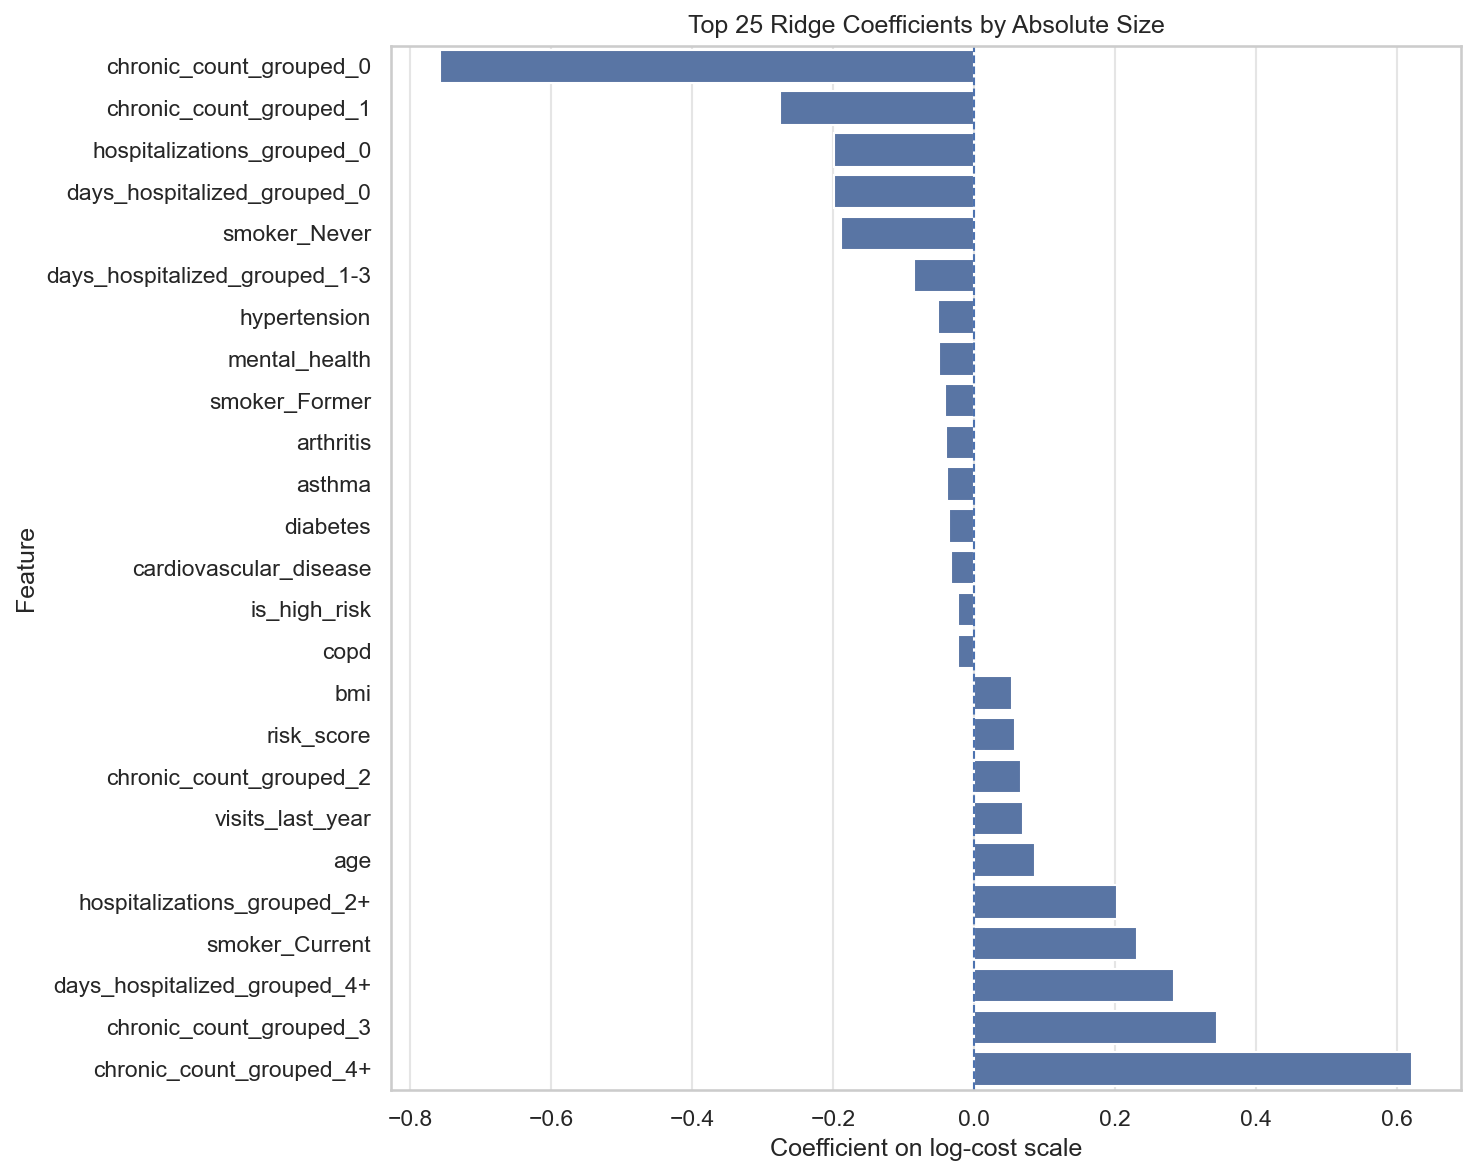

In [20]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

top_coef = coef_df.head(25).sort_values("coefficient")

sns.barplot(
    data=top_coef,
    x="coefficient",
    y="feature",
    ax=ax,
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Top 25 Ridge Coefficients by Absolute Size")
ax.set_xlabel("Coefficient on log-cost scale")
ax.set_ylabel("Feature")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_top_coefficients",
)

plt.show()

In [21]:
shap_result = run_shap_analysis(
    model=ridge_result.model,
    x_background=ridge_result.x_train,
    x_explain=ridge_result.x_test,
    model_type="linear",
    use_transformed_features=True,
    background_size=500,
    explain_size=2000,
    masker_max_samples=500,
    random_state=42,
)

display(shap_result.importance_df.head(30))

,feature,mean_abs_shap,mean_shap
0,chronic_count_grouped_0,0.375339,0.001895
1,chronic_count_grouped_1,0.129078,0.005777
2,smoker_Never,0.079853,-0.001795
3,age,0.067144,0.001913
4,smoker_Current,0.052571,-0.001385
5,visits_last_year,0.052258,-0.001368
6,risk_score,0.048820,0.001939
7,bmi,0.041566,-0.000882
8,hypertension,0.040434,-0.004925
9,mental_health,0.036556,-0.001244


In [22]:
ridge_shap_importance_export = shap_result.importance_df.head(30).copy()

display(ridge_shap_importance_export)

export_report_table(
    table=ridge_shap_importance_export,
    table_dir=TABLE_DIR,
    file_stem="tab_03_ridge_shap_importance",
    caption="Top baseline Ridge Regression SHAP feature importance values.",
    label="tab:03-ridge-shap-importance",
    index=False,
    float_format="%.4f",
)

,feature,mean_abs_shap,mean_shap
0,chronic_count_grouped_0,0.375339,0.001895
1,chronic_count_grouped_1,0.129078,0.005777
2,smoker_Never,0.079853,-0.001795
3,age,0.067144,0.001913
4,smoker_Current,0.052571,-0.001385
5,visits_last_year,0.052258,-0.001368
6,risk_score,0.048820,0.001939
7,bmi,0.041566,-0.000882
8,hypertension,0.040434,-0.004925
9,mental_health,0.036556,-0.001244


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_shap_importance.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_shap_importance.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Tables\tab_03_ridge_all_shap_importance.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/03_ridge_regression_model/Tables/tab_03_ridge_all_shap_importance.csv')

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_shap_bar.png


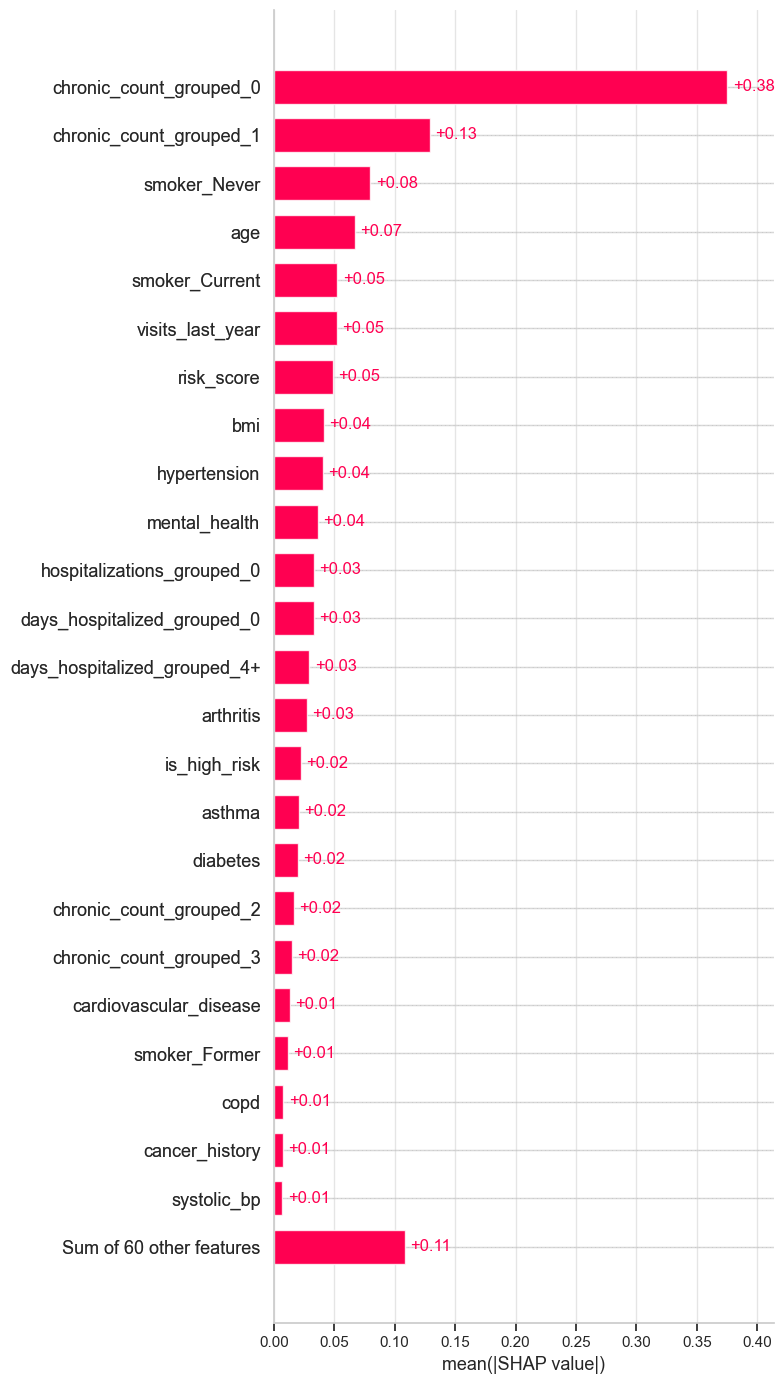

In [23]:
fig = plot_shap_bar(
    shap_result,
    max_display=25,
    show=False,
)

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_shap_bar",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_shap_beeswarm.png


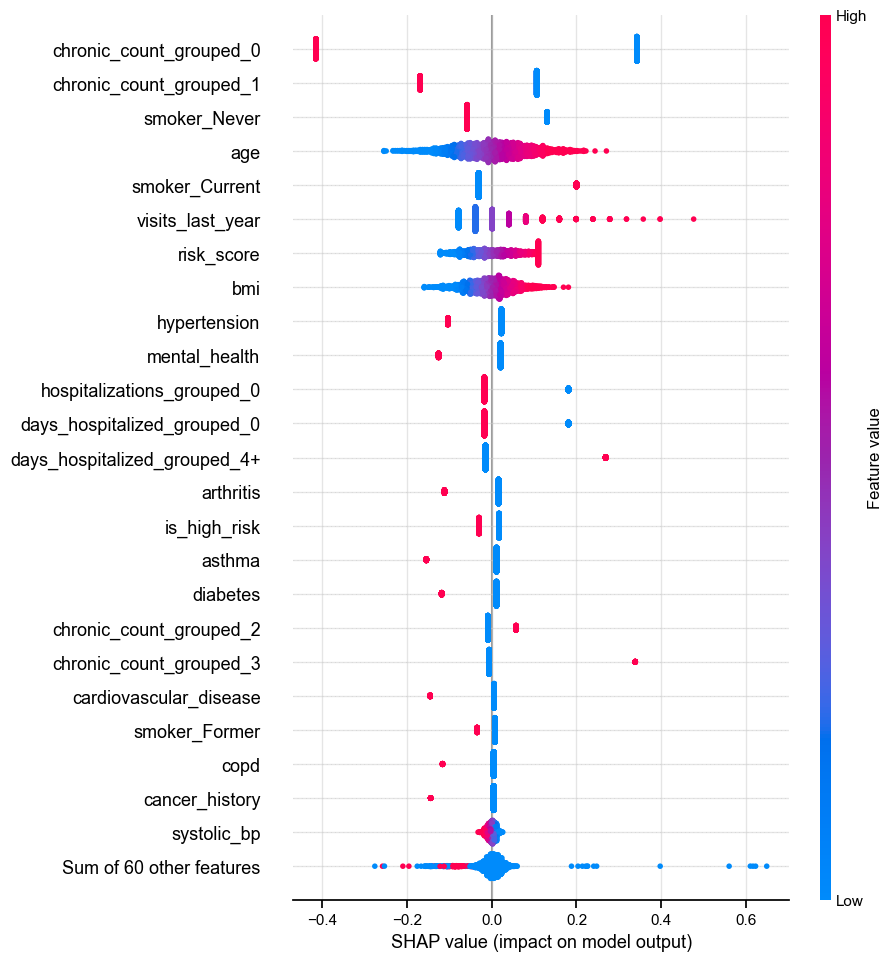

In [24]:
plot_shap_beeswarm(
    shap_result,
    max_display=25,
    text_colour="#000000",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_shap_beeswarm",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_shap_importance_dataframe.png


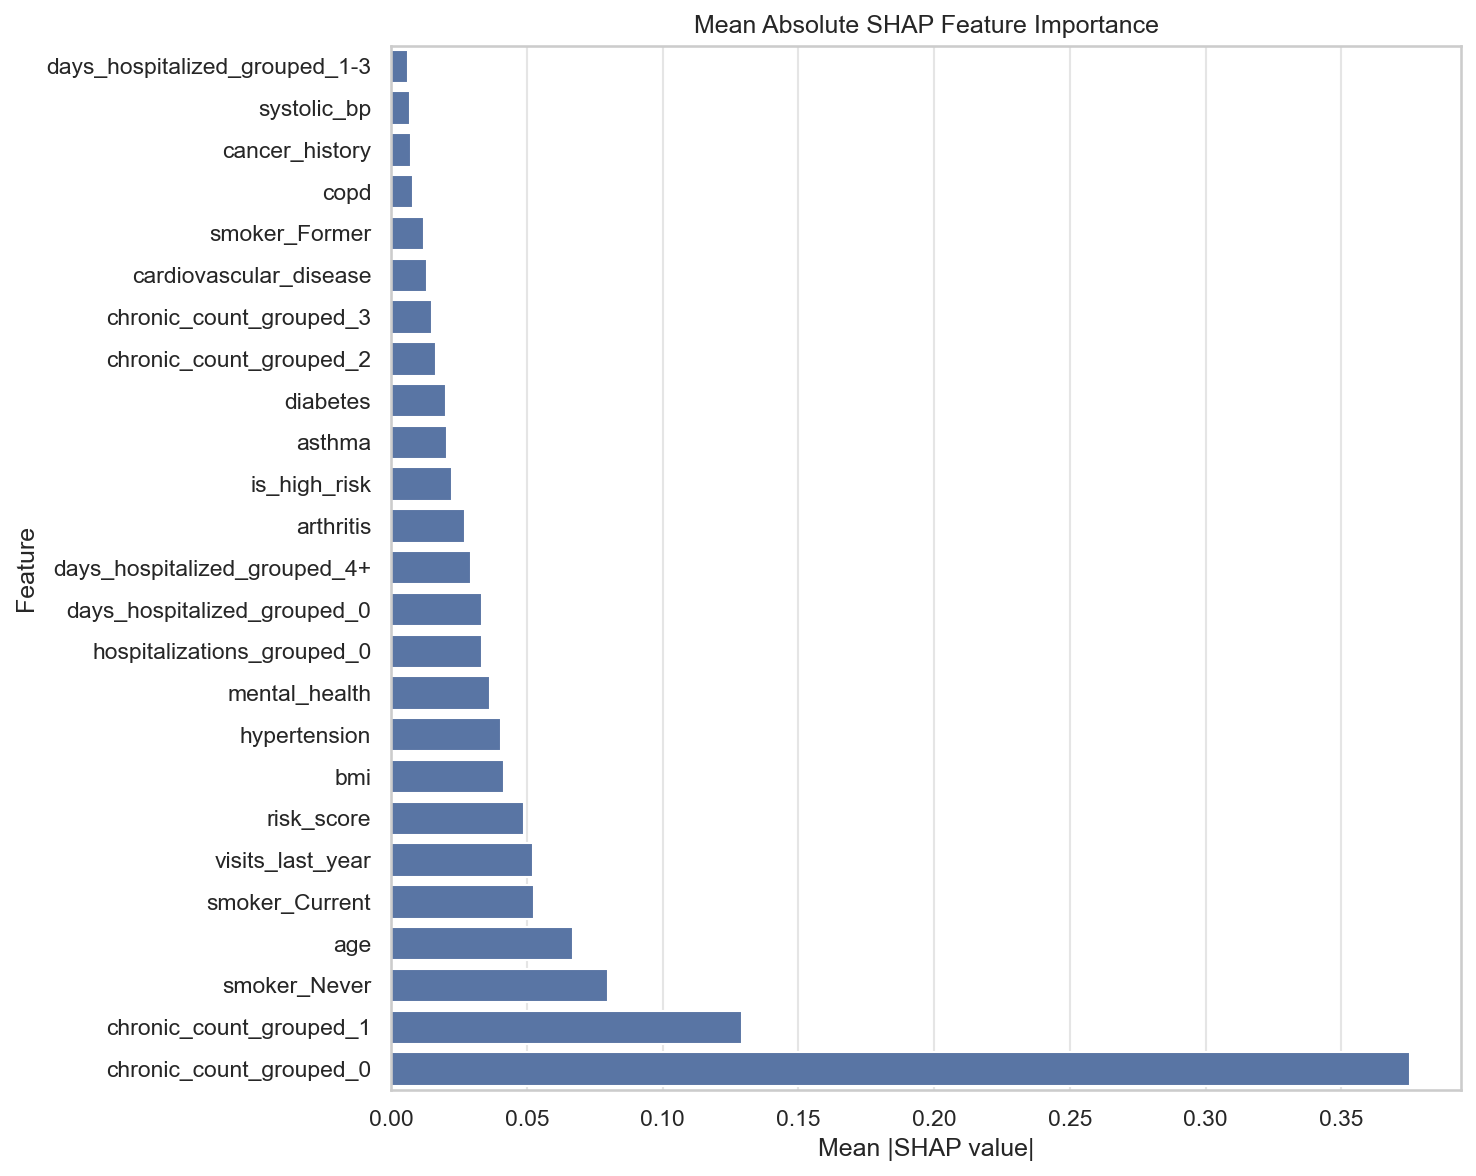

In [25]:
plot_shap_importance_dataframe(shap_result, max_display=25)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_shap_importance_dataframe",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\03_ridge_regression_model\Figures\fig_03_ridge_shap_waterfall_row_0.png


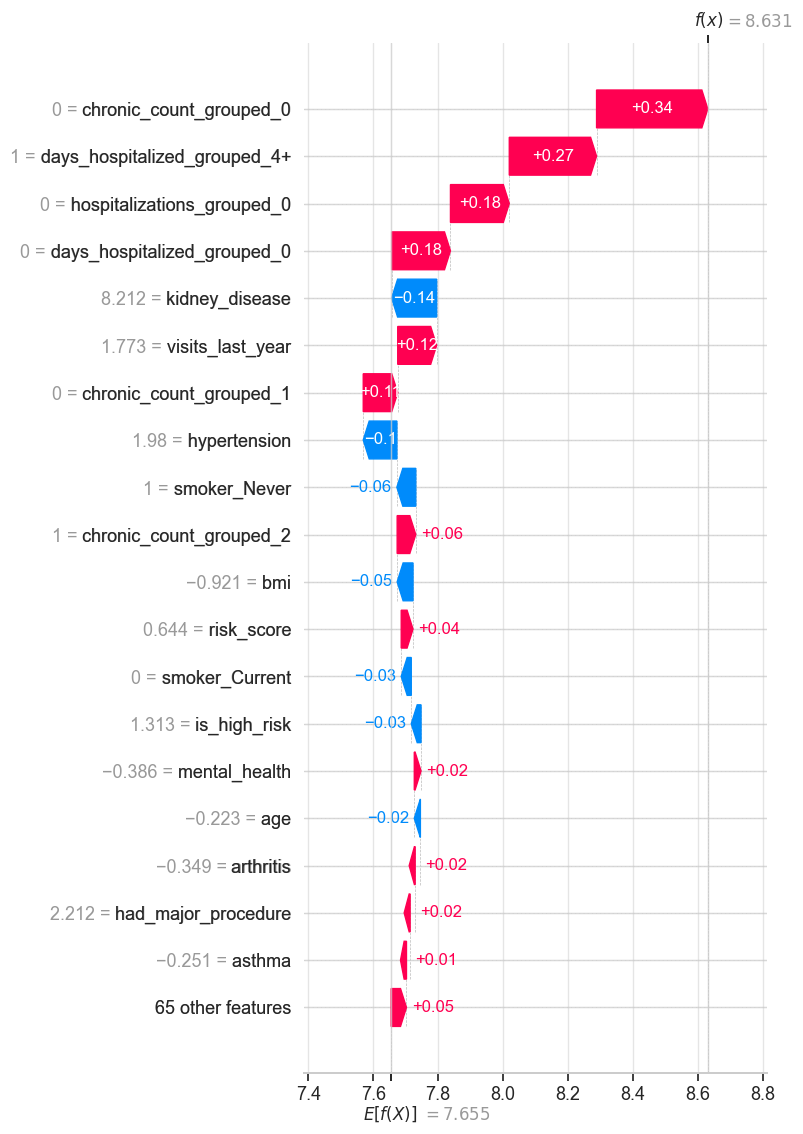

In [26]:
fig = plot_shap_waterfall(
    shap_result,
    row_number=0,
    max_display=20,
    show=False,
)

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_03_ridge_shap_waterfall_row_0",
)

plt.show()